Oppgave 2a)

/var/folders/8g/0w3fhyh11r943ccbwpxvtj_r0000gn/T/ipykernel_70403/1854012283.py:37: RuntimeWarning: overflow encountered in exp
  nevner = 1 + np.exp(-beta_k*(V(x+1)-V(x-1))) + np.exp(-beta_k*(V(x)-V(x-1)))


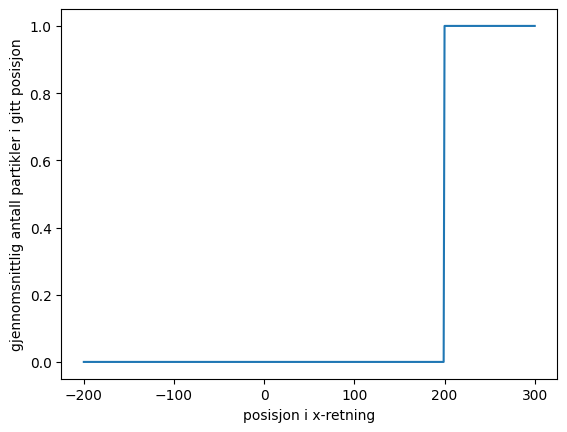

In [3]:
import numpy as np
from matplotlib import pyplot as plt
#programmet er strukturert slik at konstanter defineres først og brukes deretter globalt av funksjonene


#konstanter                      #konstant for potensialfunksjonen
beta_k = 1000
antallPartikler = 101
antallSimulasjoner = 100                                                 
timeSteps = 200
dt = 1                      #time step delta_t
h = 1                       #step length



#### Nødvendige hjelpefunksjoner

#potensialfunksjonen V(x) = k (uten k)
def V_i(x):
    return 1

#potensialfunksjonen V(x) = -kx (uten k)
def V_ii(x):
    return -x


#Henholdsvise sannsynlighetsfunksjoner p+, p0 og p-
def p_pos(x, V):
    nevner = 1 + np.exp(-beta_k*(V(x-1)-V(x+1))) + np.exp(-beta_k*(V(x)-V(x+1)))
    return 1/nevner

def p_0(x, V):
    nevner = 1 + np.exp(-beta_k*(V(x-1)-V(x))) + np.exp(-beta_k*(V(x+1)-V(x)))
    return 1/nevner

def p_neg(x, V):
    nevner = 1 + np.exp(-beta_k*(V(x+1)-V(x-1))) + np.exp(-beta_k*(V(x)-V(x-1)))
    return 1/nevner



##### Main funksjonen som kjører simulasjonen

def enSimulasjon_2a(V):                           #kan være forskjellig potensialfunksjon
    partiklerPos = np.arange(0,antallPartikler)
    for _ in range(timeSteps):
        for i in range(len(partiklerPos)):
            tilfeldigtall = np.random.rand()

            if tilfeldigtall <= p_neg(partiklerPos[i], V):
                partiklerPos[i] -= 1
            elif tilfeldigtall >= (1-p_pos(partiklerPos[i], V)):
                partiklerPos[i] += 1

    return partiklerPos

def flereSimulasjoner_2a(V):
    totalPartikler = np.zeros(antallPartikler+2*timeSteps)          #array hvor indeks 0 tilsvarer lengst mulig til venstre
    for i in range(antallSimulasjoner): 
        enSim = enSimulasjon_2a(V)
        for elem in enSim:
            totalPartikler[elem+timeSteps] += 1             #må flytte til høyre timeSteps for at lengst mulig til venstre blir 0

    return totalPartikler


averageDist = flereSimulasjoner_2a(V_ii)/antallSimulasjoner
x_aksen = np.arange(-timeSteps, antallPartikler + timeSteps)
plt.plot(x_aksen, averageDist)
plt.xlabel("posisjon i x-retning")
plt.ylabel("gjennomsnittlig antall partikler i gitt posisjon")
plt.show()

Oppgave 2b)

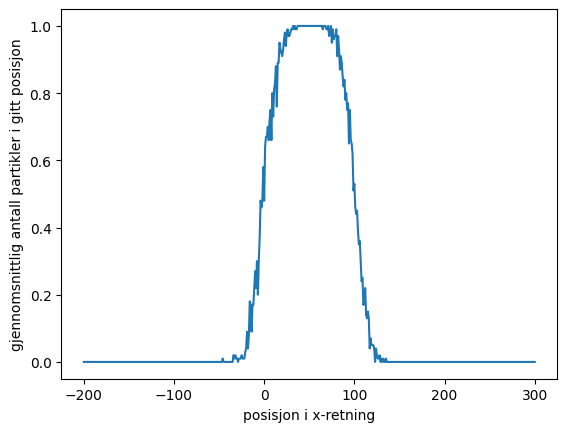

In [5]:
#gjenbruk av kode fra 2a
def enSimulasjon_2b(V):
    partiklerPos = np.arange(0,antallPartikler)
    partiklerPos_set = set(partiklerPos)
    for _ in range(timeSteps):
        tilfeldigRekkefølge = np.arange(0,antallPartikler)
        np.random.shuffle(tilfeldigRekkefølge)
        for i in tilfeldigRekkefølge:
            tilfeldigtall = np.random.rand()


            if tilfeldigtall <= p_neg(partiklerPos[i], V):
                if (partiklerPos[i]-1) not in partiklerPos_set:
                    partiklerPos_set.add(partiklerPos[i]-1)
                    partiklerPos_set.remove(partiklerPos[i])
                    partiklerPos[i] -= 1
            elif tilfeldigtall >= (1-p_pos(partiklerPos[i], V)):
                if (partiklerPos[i]+1) not in partiklerPos_set:
                    partiklerPos_set.add(partiklerPos[i]+1)
                    partiklerPos_set.remove(partiklerPos[i])
                    partiklerPos[i] += 1

    return partiklerPos



def flereSimulasjoner_2b(V):
    totalPartikler = np.zeros(antallPartikler+2*timeSteps)          #array hvor indeks 0 tilsvarer lengst mulig til venstre
    for i in range(antallSimulasjoner): 
        enSim = enSimulasjon_2b(V)
        for elem in enSim:
            totalPartikler[elem+timeSteps] += 1             #må flytte til høyre timeSteps for at lengst mulig til venstre blir 0

    return totalPartikler

averageDist = flereSimulasjoner_2b(V_i)/antallSimulasjoner
x_aksen = np.arange(-timeSteps, antallPartikler + timeSteps)
plt.plot(x_aksen, averageDist)
plt.xlabel("posisjon i x-retning")
plt.ylabel("gjennomsnittlig antall partikler i gitt posisjon")
plt.show()